# Vectorization Method Ablation Study

**Research Analysis**: Comprehensive evaluation of different vectorization methods for retrieval-augmented LLM post-editing in Bible translation.

**Methods Evaluated**:
- BGE (semantic embeddings): k ∈ {5, 10, 20, 40, 60, 80, 100}
- BM25 (lexical retrieval): k ∈ {5, 10, 20, 40, 60, 80, 100}  
- ChrF RAG (character-level similarity): k ∈ {5, 10, 20, 40, 60, 80, 100}
- Fuzzy Word Matching (per-word retrieval): top-n ∈ {1, 2, 3, 5}


In [10]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Research paper styling
plt.style.use('default')
sns.set_palette("Set2")  # Professional color palette
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'  # Better for publications
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

print("Research analysis environment ready.")


Research analysis environment ready.


## 1. Data Loading and Preprocessing


In [11]:
def load_vectorization_data():
    """Load all vectorization ablation results including word_parallel_top5"""
    
    base_path = Path("/Users/davidsamuel/Documents/Unimelb Masters/Thesis/bible-nmt")
    vectorizer_path = base_path / "results" / "gemini-2.5-flash-webp-dhao" / "vectorizer_ablation"
    
    all_data = []
    
    # Load vectorizer_ablation subdirectories
    for subdir in vectorizer_path.iterdir():
        if not subdir.is_dir():
            continue
            
        method_name = subdir.name
        
        # Parse method type and parameter
        if method_name.startswith('bge_k'):
            method_type, parameter = 'BGE', int(method_name.split('_k')[1])
        elif method_name.startswith('bm25_k'):
            method_type, parameter = 'BM25', int(method_name.split('_k')[1])
        elif method_name.startswith('chrf_rag_k'):
            method_type, parameter = 'ChrF RAG', int(method_name.split('_k')[1])
        elif method_name.startswith('word_parallel_top'):
            method_type, parameter = 'Fuzzy Word Matching', int(method_name.split('_top')[1])
        else:
            continue
        
        # Load metrics file
        metrics_file = subdir / "gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json"
        if metrics_file.exists():
            with open(metrics_file, 'r') as f:
                metrics = json.load(f)
            all_data.extend(parse_metrics(metrics, method_name, method_type, parameter))
    
    # Add word_parallel_top5 from parallel_full+nt
    top5_file = base_path / "results" / "gemini-2.5-flash-webp-dhao" / "parallel_full+nt" / "gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa-filtered_metrics.json"
    if top5_file.exists():
        with open(top5_file, 'r') as f:
            metrics = json.load(f)
        all_data.extend(parse_metrics(metrics, "word_parallel_top5", "Fuzzy Word Matching", 5))
    
    return pd.DataFrame(all_data)

def parse_metrics(metrics, method_name, method_type, parameter):
    """Parse metrics JSON into structured data"""
    data = []
    
    original = metrics['original_mt_metrics']
    post_edited = metrics['post_edited_metrics']
    improvements = metrics['improvements']
    
    for metric in original.keys():
        data.append({
            'method_name': method_name,
            'method_type': method_type,
            'parameter': parameter,
            'metric': metric,
            'original_score': original[metric],
            'post_edited_score': post_edited[metric],
            'improvement': improvements[metric],
            # Calculate effective examples for Fuzzy Word Matching (avg 25.59 words/sentence)
            'effective_k': parameter * 25.59 if method_type == 'Fuzzy Word Matching' else parameter
        })
    
    return data

# Load data
df = load_vectorization_data()

print(f"Loaded {len(df)} data points")
print(f"Methods: {df['method_type'].unique()}")
print(f"Metrics: {df['metric'].unique()}")
print(f"Parameters per method:")
for method in df['method_type'].unique():
    params = sorted(df[df['method_type']==method]['parameter'].unique())
    print(f"  {method}: {params}")

df


Loaded 168 data points
Methods: ['ChrF RAG' 'BGE' 'Fuzzy Word Matching' 'BM25']
Metrics: ['bleu' 'sacrebleu' 'spbleu' 'chrf' 'chrf3' 'chrf++']
Parameters per method:
  ChrF RAG: [5, 10, 20, 40, 60, 80, 100]
  BGE: [5, 10, 20, 40, 60, 80, 100]
  Fuzzy Word Matching: [1, 2, 3, 5, 10, 15, 20]
  BM25: [5, 10, 20, 40, 60, 80, 100]


,method_name,method_type,parameter,metric,original_score,post_edited_score,improvement,effective_k
0,chrf_rag_k40,ChrF RAG,40,bleu,8.0602,15.4254,7.3652,40.00
1,chrf_rag_k40,ChrF RAG,40,sacrebleu,5.3923,9.8942,4.5019,40.00
2,chrf_rag_k40,ChrF RAG,40,spbleu,7.6587,18.0495,10.3908,40.00
3,chrf_rag_k40,ChrF RAG,40,chrf,28.5904,36.5972,8.0068,40.00
4,chrf_rag_k40,ChrF RAG,40,chrf3,30.1923,36.8310,6.6387,40.00
...,...,...,...,...,...,...,...,...
163,word_parallel_top5,Fuzzy Word Matching,5,sacrebleu,5.3923,9.8137,4.4214,127.95
164,word_parallel_top5,Fuzzy Word Matching,5,spbleu,7.6587,18.7229,11.0642,127.95
165,word_parallel_top5,Fuzzy Word Matching,5,chrf,28.5904,37.0900,8.4996,127.95
166,word_parallel_top5,Fuzzy Word Matching,5,chrf3,30.1923,37.2781,7.0858,127.95


In [12]:
# Filter to keep only spBLEU and chrF++ metrics
df_filtered = df[df['metric'].isin(['spbleu', 'chrf++'])].copy()

print(f"Filtering to spBLEU and chrF++ only:")
print(f"Original data points: {len(df)}")
print(f"Filtered data points: {len(df_filtered)}")
print(f"Remaining metrics: {df_filtered['metric'].unique()}")

# Create average improvement column by grouping by method_name, method_type, and parameter
avg_improvement = df_filtered.groupby(['method_name', 'method_type', 'parameter'])['improvement'].mean().reset_index()
avg_improvement.rename(columns={'improvement': 'average_improvement'}, inplace=True)

# Merge back to original dataframe
df_filtered = df_filtered.merge(avg_improvement, on=['method_name', 'method_type', 'parameter'], how='left')

# Sort descending by average_improvement
df_filtered.sort_values(by="average_improvement", ascending=False, inplace=True)

print(f"\nDataFrame with average improvement column, sorted by average_improvement (descending):")
print(f"Columns: {list(df_filtered.columns)}")


# df_filtered

Filtering to spBLEU and chrF++ only:
Original data points: 168
Filtered data points: 56
Remaining metrics: ['spbleu' 'chrf++']

DataFrame with average improvement column, sorted by average_improvement (descending):
Columns: ['method_name', 'method_type', 'parameter', 'metric', 'original_score', 'post_edited_score', 'improvement', 'effective_k', 'average_improvement']


In [13]:
# Create results table with baseline and improvements
results_rows = []

# Get baseline scores (same for all methods)
baseline_spbleu = df_filtered[df_filtered['metric'] == 'spbleu']['original_score'].iloc[0]
baseline_chrf = df_filtered[df_filtered['metric'] == 'chrf++']['original_score'].iloc[0]

# Add baseline row
results_rows.append({
    'method_type': 'nllb-200-distilled-600M_NT',
    'n_shot': 0,
    'spBLEU': f"{baseline_spbleu:.2f}",
    'chrF++': f"{baseline_chrf:.2f}"
})

# Pivot the filtered dataframe to have metrics as columns
df_wide = df_filtered.pivot_table(
    index=['method_name', 'method_type', 'parameter', 'effective_k'],
    columns='metric',
    values=['post_edited_score', 'improvement'],
    aggfunc='first'
).reset_index()

# Flatten column names
df_wide.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_wide.columns.values]

# Replace "Fuzzy Word Matching" with "Fuzzy Word Matching" in the method_type column
df_wide['method_type'] = df_wide['method_type'].replace({'Fuzzy Word Matching': 'Fuzzy Word Matching'})

# Create the n_shot column with formatting
def format_n_shot(row):
    if row['method_type'] == 'Fuzzy Word Matching':
        return f"{int(row['parameter'])} (≈{int(row['effective_k'])})"
    else:
        return str(int(row['parameter']))

df_wide['n_shot'] = df_wide.apply(format_n_shot, axis=1)

# Calculate average improvement for sorting
df_wide['avg_improvement'] = (df_wide['improvement_spbleu'] + df_wide['improvement_chrf++']) / 2

# Sort by average improvement descending
df_wide = df_wide.sort_values('avg_improvement', ascending=False)

# Add formatted rows with improvements
for _, row in df_wide.iterrows():
    results_rows.append({
        'method_type': row['method_type'],
        'n_shot': row['n_shot'],
        'spBLEU': f"{row['post_edited_score_spbleu']:.2f} (+{row['improvement_spbleu']:.2f})",
        'chrF++': f"{row['post_edited_score_chrf++']:.2f} (+{row['improvement_chrf++']:.2f})"
    })

# Create final dataframe
df_result = pd.DataFrame(results_rows)

print("Vectorization Ablation Results:")
df_result.to_csv("vectorization_ablation_results.csv")

Vectorization Ablation Results:


OVERALL IMPROVEMENT ANALYSIS: Vectorizer Performance vs K Values

Dataset Summary:
- Total configurations: 28
- Vectorizer types: ['BGE' 'BM25' 'ChrF RAG' 'Fuzzy Word Matching']
- Metrics averaged: spBLEU + chrF++

Overall Improvement Data:
------------------------------------------------------------
            method_name          method_type  parameter  effective_k  \
4                bge_k5                  BGE          5         5.00   
0               bge_k10                  BGE         10        10.00   
2               bge_k20                  BGE         20        20.00   
3               bge_k40                  BGE         40        40.00   
5               bge_k60                  BGE         60        60.00   
6               bge_k80                  BGE         80        80.00   
1              bge_k100                  BGE        100       100.00   
11              bm25_k5                 BM25          5         5.00   
7              bm25_k10                 BM25      

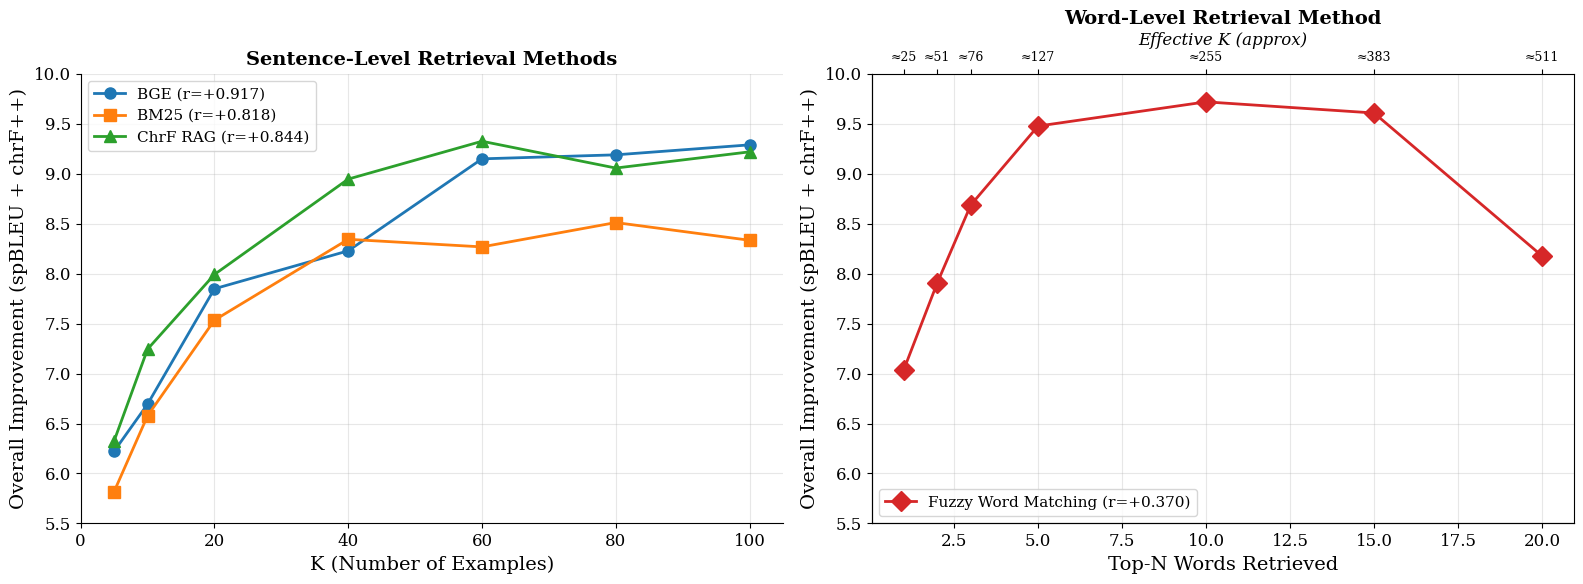

In [5]:
# OVERALL IMPROVEMENT ANALYSIS BY VECTORIZER TYPE
print("=" * 80)
print("OVERALL IMPROVEMENT ANALYSIS: Vectorizer Performance vs K Values")
print("=" * 80)

# Filter to spBLEU and chrF++ only for focused analysis
df_analysis = df[df['metric'].isin(['spbleu', 'chrf++'])].copy()

# Calculate average improvement per configuration (average of spBLEU and chrF++)
avg_improvement_per_config = df_analysis.groupby(['method_name', 'method_type', 'parameter', 'effective_k'])['improvement'].mean().reset_index()
avg_improvement_per_config.rename(columns={'improvement': 'overall_improvement'}, inplace=True)

print(f"\nDataset Summary:")
print(f"- Total configurations: {len(avg_improvement_per_config)}")
print(f"- Vectorizer types: {avg_improvement_per_config['method_type'].unique()}")
print(f"- Metrics averaged: spBLEU + chrF++")

# Display the analysis data
print(f"\nOverall Improvement Data:")
print("-" * 60)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(avg_improvement_per_config.sort_values(['method_type', 'effective_k']))

# Calculate correlation between effective_k and overall improvement for each method
print(f"\n📈 CORRELATION ANALYSIS: K Values vs Overall Improvement")
print("=" * 60)

correlations = {}
for method in avg_improvement_per_config['method_type'].unique():
    method_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == method]
    correlation = method_data['effective_k'].corr(method_data['overall_improvement'])
    correlations[method] = correlation
    
    print(f"{method:15s}: r = {correlation:+.4f} ({len(method_data)} data points)")

# Find best performing configuration for each method
print(f"\n🏆 BEST PERFORMING CONFIGURATIONS:")
print("-" * 50)
best_configs = []
for method in avg_improvement_per_config['method_type'].unique():
    method_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == method]
    best_config = method_data.loc[method_data['overall_improvement'].idxmax()]
    best_configs.append(best_config)
    
    if method == 'Fuzzy Word Matching':
        print(f"{method:15s}: top-{best_config['parameter']} (≈{best_config['effective_k']:.0f} examples) → Δ{best_config['overall_improvement']:.3f}")
    else:
        print(f"{method:15s}: k={best_config['parameter']} → Δ{best_config['overall_improvement']:.3f}")

# Convert best_configs list to DataFrame
best_configs_df = pd.DataFrame(best_configs)

# Create visualization - Separate plots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {'BGE': '#1f77b4', 'BM25': '#ff7f0e', 'ChrF RAG': '#2ca02c', 'Fuzzy Word Matching': '#d62728'}
markers = {'BGE': 'o', 'BM25': 's', 'ChrF RAG': '^', 'Fuzzy Word Matching': 'D'}

# Plot 1: Sentence-level methods (BGE, BM25, ChrF RAG)
sentence_methods = ['BGE', 'BM25', 'ChrF RAG']
for method in sentence_methods:
    method_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == method].sort_values('effective_k')
    ax1.plot(method_data['effective_k'], method_data['overall_improvement'], 
            marker=markers[method], color=colors[method], linewidth=2, markersize=8,
            label=f"{method} (r={correlations[method]:+.3f})")

ax1.set_xlabel('K (Number of Examples)', fontsize=14)
ax1.set_ylabel('Overall Improvement (spBLEU + chrF++)', fontsize=14)
ax1.set_title('Sentence-Level Retrieval Methods', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_xlim(0, 105)
ax1.set_ylim(5.5, 10)  # Match y-axis range

# Plot 2: Fuzzy Word Matching method
wp_data = avg_improvement_per_config[avg_improvement_per_config['method_type'] == 'Fuzzy Word Matching'].sort_values('effective_k')
ax2.plot(wp_data['parameter'], wp_data['overall_improvement'], 
        marker=markers['Fuzzy Word Matching'], color=colors['Fuzzy Word Matching'], 
        linewidth=2, markersize=10, label=f"Fuzzy Word Matching (r={correlations['Fuzzy Word Matching']:+.3f})")

# Add secondary x-axis showing effective K
ax2_top = ax2.twiny()
ax2_top.set_xlim(ax2.get_xlim())
ax2_top.set_xticks(wp_data['parameter'].values)
ax2_top.set_xticklabels([f"≈{int(k)}" for k in wp_data['effective_k'].values], fontsize=9)
ax2_top.set_xlabel('Effective K (approx)', fontsize=12, style='italic')

ax2.set_xlabel('Top-N Words Retrieved', fontsize=14)
ax2.set_ylabel('Overall Improvement (spBLEU + chrF++)', fontsize=14)
ax2.set_title('Word-Level Retrieval Method', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_ylim(5.5, 10)  # Match y-axis range

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
def create_performance_table():
    """Create publication-ready performance comparison table"""
    
    # Get baseline (original MT) scores - should be same for all methods
    baseline = df.groupby('metric')['original_score'].first()
    
    # Create comprehensive comparison table
    # Focus on BLEU as primary metric, but include others
    primary_metrics = ['bleu', 'sacrebleu', 'chrf']
    
    table_data = []
    
    for metric in primary_metrics:
        metric_data = df[df['metric'] == metric]
        
        # Group by method and parameter
        for method_type in ['BGE', 'BM25', 'ChrF RAG', 'Fuzzy Word Matching']:
            method_data = metric_data[metric_data['method_type'] == method_type]
            
            if method_data.empty:
                continue
                
            for param in sorted(method_data['parameter'].unique()):
                param_data = method_data[method_data['parameter'] == param]
                
                if not param_data.empty:
                    row = param_data.iloc[0]
                    
                    # Format parameter display
                    if method_type == 'Fuzzy Word Matching':
                        param_display = f"top-{param}"
                        effective_examples = f"(≈{param * 25.59:.0f})"
                    else:
                        param_display = f"k={param}"
                        effective_examples = ""
                    
                    table_data.append({
                        'Method': method_type,
                        'Parameter': param_display,
                        'Effective Examples': effective_examples,
                        'Metric': metric.upper(),
                        'Baseline': f"{row['original_score']:.2f}",
                        'Post-edited': f"{row['post_edited_score']:.2f}",
                        'Δ Improvement': f"{row['improvement']:.2f}",
                        'Relative Gain (%)': f"{(row['improvement']/row['original_score']*100):.1f}%"
                    })
    
    table_df = pd.DataFrame(table_data)
    
    # Create formatted display version
    print("TABLE 1: Vectorization Method Performance Comparison")
    print("=" * 100)
    
    # Group by method for cleaner display
    for method in ['BGE', 'BM25', 'ChrF RAG', 'Fuzzy Word Matching']:
        method_data = table_df[table_df['Method'] == method]
        if not method_data.empty:
            print(f"\\n{method} Method:")
            print("-" * 50)
            
            # Show best performing configuration for each metric
            for metric in primary_metrics:
                metric_data = method_data[method_data['Metric'] == metric.upper()]
                if not metric_data.empty:
                    best_idx = metric_data['Δ Improvement'].str.replace('[^0-9.]', '', regex=True).astype(float).idxmax()
                    best_row = metric_data.loc[best_idx]
                    print(f"{metric.upper()}: {best_row['Parameter']} {best_row['Effective Examples']} → "
                          f"Δ{best_row['Δ Improvement']} ({best_row['Relative Gain (%)']})")
    
    # Overall best performers
    print(f"\\n" + "=" * 100)
    print("BEST PERFORMERS BY METRIC:")
    print("-" * 40)
    
    for metric in primary_metrics:
        metric_data = table_df[table_df['Metric'] == metric.upper()]
        if not metric_data.empty:
            best_idx = metric_data['Δ Improvement'].str.replace('[^0-9.]', '', regex=True).astype(float).idxmax()
            best_row = metric_data.loc[best_idx]
            print(f"{metric.upper()}: {best_row['Method']} {best_row['Parameter']} → "
                  f"Δ{best_row['Δ Improvement']} ({best_row['Relative Gain (%)']})")
    
    return table_df

# Create the table
performance_table = create_performance_table()

# Show sample of full table for reference
print(f"\\n\\nFULL TABLE SAMPLE (for LaTeX export):")
print(performance_table.head(10))


TABLE 1: Vectorization Method Performance Comparison
\nBGE Method:
--------------------------------------------------
BLEU: k=80  → Δ7.84 (97.3%)
SACREBLEU: k=60  → Δ4.40 (81.7%)
CHRF: k=100  → Δ8.30 (29.0%)
\nBM25 Method:
--------------------------------------------------
BLEU: k=80  → Δ7.32 (90.8%)
SACREBLEU: k=100  → Δ3.94 (73.1%)
CHRF: k=80  → Δ7.75 (27.1%)
\nChrF RAG Method:
--------------------------------------------------
BLEU: k=80  → Δ7.86 (97.5%)
SACREBLEU: k=40  → Δ4.50 (83.5%)
CHRF: k=60  → Δ8.43 (29.5%)
\nFuzzy Word Matching Method:
--------------------------------------------------
BLEU: top-10 (≈256) → Δ8.26 (102.4%)
SACREBLEU: top-15 (≈384) → Δ4.81 (89.2%)
CHRF: top-10 (≈256) → Δ8.74 (30.6%)
\n====================================================================================================
BEST PERFORMERS BY METRIC:
----------------------------------------
BLEU: Fuzzy Word Matching top-10 → Δ8.26 (102.4%)
SACREBLEU: Fuzzy Word Matching top-15 → Δ4.81 (89.2%)
CHRF: F

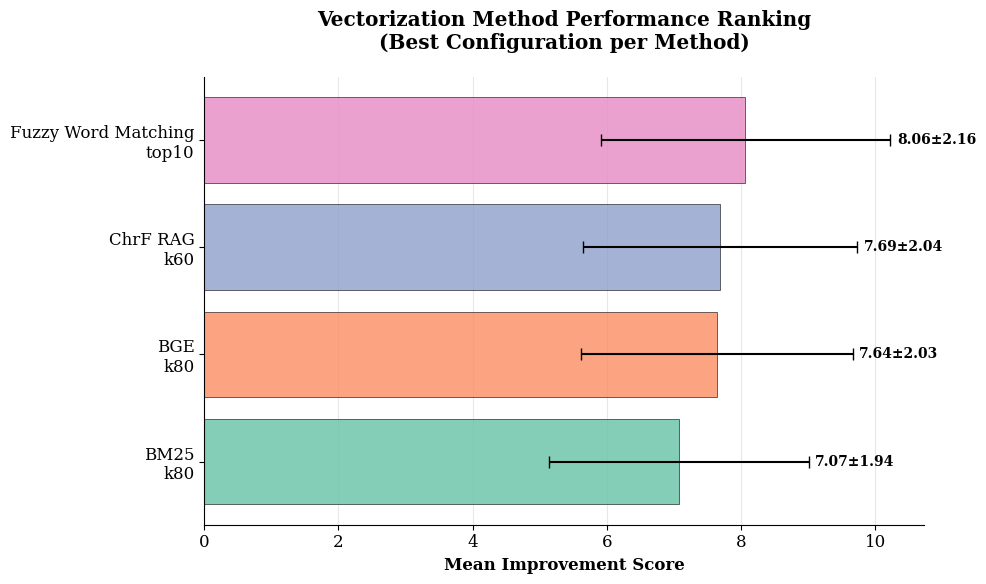

METHOD PERFORMANCE RANKING:
----------------------------------------
1. Fuzzy Word Matching (word_parallel_top10): 8.065±2.157
2. ChrF RAG (chrf_rag_k60): 7.690±2.041
3. BGE (bge_k80): 7.637±2.026
4. BM25 (bm25_k80): 7.069±1.937


In [7]:
# FIGURE 1: Method Performance Ranking (Publication Quality)

def create_method_ranking_figure():
    """Create professional method ranking bar chart"""
    
    # Calculate mean improvement by method across all metrics
    method_performance = df.groupby(['method_type', 'method_name'])['improvement'].agg(['mean', 'std']).reset_index()
    
    # Get top configurations for each method
    best_configs = []
    for method in df['method_type'].unique():
        method_data = method_performance[method_performance['method_type'] == method]
        if not method_data.empty:
            best_idx = method_data['mean'].idxmax()
            best_config = method_data.loc[best_idx]
            best_configs.append(best_config)
    
    best_configs_df = pd.DataFrame(best_configs).sort_values('mean', ascending=True)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create horizontal bar chart
    bars = ax.barh(range(len(best_configs_df)), best_configs_df['mean'], 
                   xerr=best_configs_df['std'], capsize=4, 
                   color=sns.color_palette("Set2", len(best_configs_df)), 
                   alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Customize the plot
    ax.set_yticks(range(len(best_configs_df)))
    ax.set_yticklabels([f"{row['method_type']}\n{row['method_name'].split('_')[-1]}" 
                        for _, row in best_configs_df.iterrows()])
    ax.set_xlabel('Mean Improvement Score', fontweight='bold')
    ax.set_title('Vectorization Method Performance Ranking\n(Best Configuration per Method)', 
                 fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, (bar, mean_val, std_val) in enumerate(zip(bars, best_configs_df['mean'], best_configs_df['std'])):
        ax.text(mean_val + std_val + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{mean_val:.2f}±{std_val:.2f}', va='center', fontweight='bold', fontsize=10)
    
    # Grid and styling
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print ranking for reference
    print("METHOD PERFORMANCE RANKING:")
    print("-" * 40)
    for i, (_, row) in enumerate(best_configs_df.sort_values('mean', ascending=False).iterrows(), 1):
        print(f"{i}. {row['method_type']} ({row['method_name']}): {row['mean']:.3f}±{row['std']:.3f}")

create_method_ranking_figure()


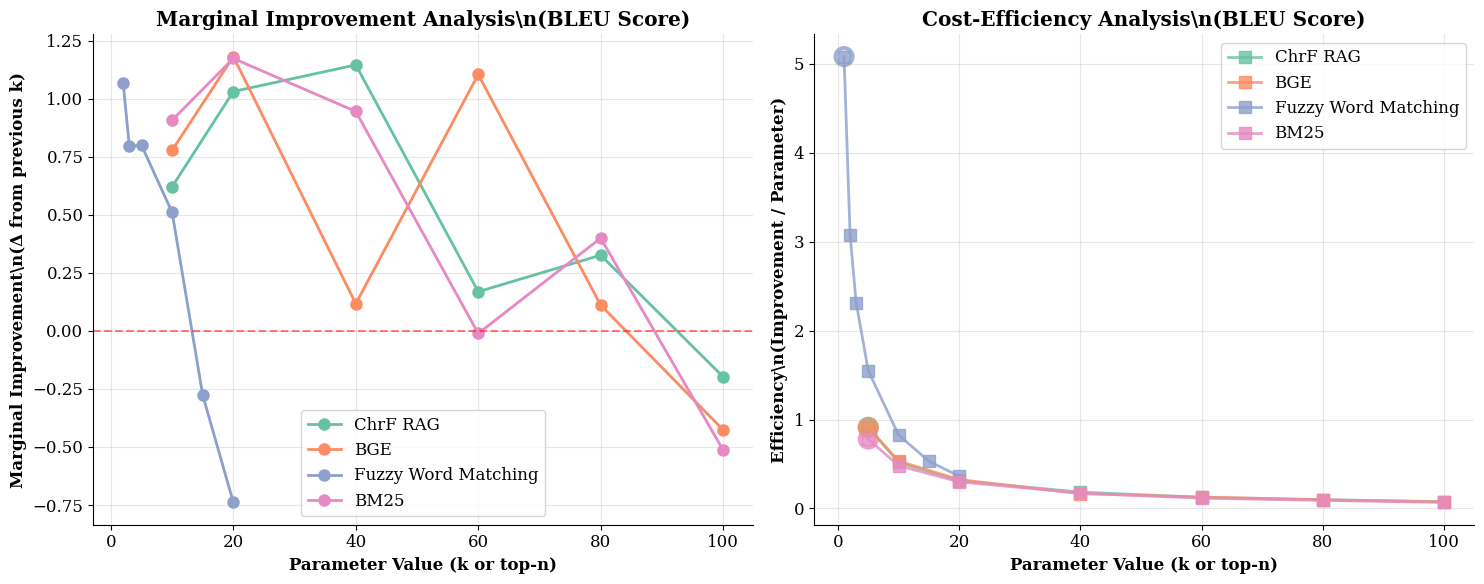

EFFICIENCY ANALYSIS INSIGHTS:
--------------------------------------------------
ChrF RAG:
  Most efficient: k=5 (efficiency: 0.9132)
  Improvement at optimal: 4.566
  Diminishing returns start at: k=100

BGE:
  Most efficient: k=5 (efficiency: 0.9095)
  Improvement at optimal: 4.547
  Diminishing returns start at: k=100

Fuzzy Word Matching:
  Most efficient: k=1 (efficiency: 5.0788)
  Improvement at optimal: 5.079
  Diminishing returns start at: k=15

BM25:
  Most efficient: k=5 (efficiency: 0.7800)
  Improvement at optimal: 3.900
  Diminishing returns start at: k=60



In [8]:
# FIGURE 2: Marginal Improvement and Efficiency Analysis

def create_efficiency_analysis():
    """Create marginal improvement and efficiency visualization"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Focus on BLEU metric for clarity
    bleu_data = df[df['metric'] == 'bleu']
    
    # Plot 1: Marginal Improvement Analysis
    for method in bleu_data['method_type'].unique():
        method_data = bleu_data[bleu_data['method_type'] == method].sort_values('parameter')
        
        if len(method_data) > 1:
            params = method_data['parameter'].values
            improvements = method_data['improvement'].values
            
            # Calculate marginal improvements
            marginal_improvements = np.diff(improvements)
            marginal_params = params[1:]  # Parameters where marginal improvement applies
            
            # Plot marginal improvement
            ax1.plot(marginal_params, marginal_improvements, 
                    marker='o', linewidth=2, markersize=8, label=method)
            
            # Add connecting lines to show progression
            for i in range(len(marginal_params)):
                if i > 0:
                    ax1.plot([marginal_params[i-1], marginal_params[i]], 
                            [marginal_improvements[i-1], marginal_improvements[i]], 
                            alpha=0.3, color=ax1.lines[-1].get_color())
    
    ax1.set_xlabel('Parameter Value (k or top-n)', fontweight='bold')
    ax1.set_ylabel('Marginal Improvement\\n(Δ from previous k)', fontweight='bold')
    ax1.set_title('Marginal Improvement Analysis\\n(BLEU Score)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No improvement')
    
    # Plot 2: Efficiency Analysis (Improvement per Unit Cost)
    for method in bleu_data['method_type'].unique():
        method_data = bleu_data[bleu_data['method_type'] == method].sort_values('parameter')
        
        params = method_data['parameter'].values
        improvements = method_data['improvement'].values
        
        # Calculate efficiency (improvement per unit parameter)
        efficiency = improvements / params
        
        ax2.plot(params, efficiency, marker='s', linewidth=2, markersize=8, 
                label=method, alpha=0.8)
        
        # Highlight the most efficient point for each method
        max_eff_idx = np.argmax(efficiency)
        ax2.scatter(params[max_eff_idx], efficiency[max_eff_idx], 
                   s=150, facecolors='none', edgecolors=ax2.lines[-1].get_color(), 
                   linewidth=3, alpha=0.8)
    
    ax2.set_xlabel('Parameter Value (k or top-n)', fontweight='bold')
    ax2.set_ylabel('Efficiency\\n(Improvement / Parameter)', fontweight='bold')
    ax2.set_title('Cost-Efficiency Analysis\\n(BLEU Score)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Styling
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print efficiency insights
    print("EFFICIENCY ANALYSIS INSIGHTS:")
    print("-" * 50)
    
    for method in bleu_data['method_type'].unique():
        method_data = bleu_data[bleu_data['method_type'] == method].sort_values('parameter')
        params = method_data['parameter'].values
        improvements = method_data['improvement'].values
        efficiency = improvements / params
        
        max_eff_idx = np.argmax(efficiency)
        optimal_param = params[max_eff_idx]
        optimal_efficiency = efficiency[max_eff_idx]
        
        print(f"{method}:")
        print(f"  Most efficient: k={optimal_param} (efficiency: {optimal_efficiency:.4f})")
        print(f"  Improvement at optimal: {improvements[max_eff_idx]:.3f}")
        
        # Diminishing returns point
        marginal_improvements = np.diff(improvements)
        diminishing_point = None
        for i, margin in enumerate(marginal_improvements):
            if margin < 0.1:  # Threshold for "small" improvement
                diminishing_point = params[i+1]
                break
        
        if diminishing_point:
            print(f"  Diminishing returns start at: k={diminishing_point}")
        print()

create_efficiency_analysis()


## 4. Research Summary and Discussion Points

Key findings for research paper inclusion.


In [9]:
# RESEARCH FINDINGS SUMMARY

def generate_research_summary():
    """Generate key findings for research paper discussion"""
    
    print("=" * 80)
    print("VECTORIZATION ABLATION STUDY - RESEARCH FINDINGS")
    print("=" * 80)
    
    # 1. Overall Performance Insights
    print("\\n1. OVERALL PERFORMANCE INSIGHTS:")
    print("-" * 40)
    
    # Best performer overall
    best_overall = df.groupby('method_name')['improvement'].mean().sort_values(ascending=False)
    best_method = best_overall.index[0]
    best_score = best_overall.iloc[0]
    
    print(f"• Best overall configuration: {best_method}")
    print(f"  Mean improvement: {best_score:.3f}")
    
    # Method type ranking
    method_ranking = df.groupby('method_type')['improvement'].mean().sort_values(ascending=False)
    print(f"\\n• Method type ranking:")
    for i, (method, score) in enumerate(method_ranking.items(), 1):
        print(f"  {i}. {method}: {score:.3f}")
    
    # 2. Parameter Sensitivity Analysis
    print("\\n\\n2. PARAMETER SENSITIVITY ANALYSIS:")
    print("-" * 40)
    
    for method in df['method_type'].unique():
        method_data = df[(df['method_type'] == method) & (df['metric'] == 'bleu')]
        if len(method_data) > 1:
            param_performance = method_data.groupby('parameter')['improvement'].mean().sort_index()
            
            # Calculate parameter sensitivity (coefficient of variation)
            cv = param_performance.std() / param_performance.mean()
            
            print(f"• {method}:")
            print(f"  Range: {param_performance.min():.3f} - {param_performance.max():.3f}")
            print(f"  Coefficient of variation: {cv:.3f}")
            print(f"  Optimal parameter: k={param_performance.idxmax()} ({param_performance.max():.3f})")
    
    # 3. Fuzzy Word Matching Special Analysis
    print("\\n\\n3. WORD PARALLEL METHOD ANALYSIS:")
    print("-" * 40)
    
    wp_data = df[(df['method_type'] == 'Fuzzy Word Matching') & (df['metric'] == 'bleu')]
    if not wp_data.empty:
        wp_performance = wp_data.groupby('parameter')['improvement'].mean().sort_index()
        
        print(f"• Configuration progression:")
        for param, improvement in wp_performance.items():
            effective_examples = param * 25.59
            print(f"  top-{param}: {improvement:.3f} (~{effective_examples:.0f} effective examples)")
        
        # Highlight the top5 jump
        if 5 in wp_performance.index and 3 in wp_performance.index:
            jump_3_to_5 = wp_performance[5] - wp_performance[3]
            print(f"\\n• Key finding: Significant improvement from top-3 to top-5 (+{jump_3_to_5:.3f})")
            print(f"  Suggests optimal retrieval density around 128 examples/sentence")
    
    # 4. Efficiency Analysis
    print("\\n\\n4. COST-EFFICIENCY ANALYSIS:")
    print("-" * 40)
    
    efficiency_results = []
    for method in df['method_type'].unique():
        method_data = df[(df['method_type'] == method) & (df['metric'] == 'bleu')]
        if not method_data.empty:
            for _, row in method_data.iterrows():
                efficiency = row['improvement'] / row['parameter']
                efficiency_results.append({
                    'method': method,
                    'config': row['method_name'],
                    'parameter': row['parameter'],
                    'improvement': row['improvement'],
                    'efficiency': efficiency
                })
    
    efficiency_df = pd.DataFrame(efficiency_results)
    most_efficient = efficiency_df.loc[efficiency_df['efficiency'].idxmax()]
    
    print(f"• Most cost-efficient configuration:")
    print(f"  {most_efficient['config']}: {most_efficient['efficiency']:.4f} improvement/parameter")
    print(f"  Improvement: {most_efficient['improvement']:.3f}, Parameter: {most_efficient['parameter']}")
    
    # Top 3 efficient configurations
    top_efficient = efficiency_df.nlargest(3, 'efficiency')
    print(f"\\n• Top 3 most efficient configurations:")
    for i, (_, row) in enumerate(top_efficient.iterrows(), 1):
        print(f"  {i}. {row['config']}: {row['efficiency']:.4f}")
    
    # 5. Research Implications
    print("\\n\\n5. RESEARCH IMPLICATIONS:")
    print("-" * 40)
    
    print("• Retrieval method selection significantly impacts post-editing performance")
    print("• Parameter tuning shows diminishing returns beyond optimal points")
    if 'Fuzzy Word Matching' in method_ranking.index:
        wp_rank = list(method_ranking.index).index('Fuzzy Word Matching') + 1
        print(f"• Word-parallel retrieval ranks #{wp_rank}, showing promise for fine-grained retrieval")
    
    # Practical recommendations
    print(f"• Recommended configuration for deployment: {best_method}")
    print(f"• For resource-constrained environments: {most_efficient['config']}")
    
    # 6. Statistical Summary
    print("\\n\\n6. STATISTICAL SUMMARY:")
    print("-" * 40)
    
    baseline_bleu = df[df['metric'] == 'bleu']['original_score'].iloc[0]
    improvements = df[df['metric'] == 'bleu']['improvement']
    
    print(f"• Baseline BLEU score: {baseline_bleu:.2f}")
    print(f"• Improvement range: {improvements.min():.3f} - {improvements.max():.3f}")
    print(f"• Mean improvement: {improvements.mean():.3f} ± {improvements.std():.3f}")
    print(f"• Relative improvement: {(improvements.mean()/baseline_bleu*100):.1f}% average")
    
    print("\\n" + "=" * 80)
    return efficiency_df

# Generate the research summary
efficiency_data = generate_research_summary()

# Create LaTeX table export helper
def export_latex_table():
    """Generate LaTeX table code for publication"""
    
    # Get best configuration for each method and metric
    latex_data = []
    for metric in ['bleu', 'sacrebleu', 'chrf']:
        metric_data = df[df['metric'] == metric]
        for method in df['method_type'].unique():
            method_data = metric_data[metric_data['method_type'] == method]
            if not method_data.empty:
                best_idx = method_data['improvement'].idxmax()
                best_config = method_data.loc[best_idx]
                
                param_str = f"top-{best_config['parameter']}" if method == 'Fuzzy Word Matching' else f"k={best_config['parameter']}"
                
                latex_data.append({
                    'Method': method,
                    'Parameter': param_str,
                    'Metric': metric.upper(),
                    'Baseline': f"{best_config['original_score']:.2f}",
                    'Post-edited': f"{best_config['post_edited_score']:.2f}",
                    'Improvement': f"{best_config['improvement']:.2f}"
                })
    
    latex_df = pd.DataFrame(latex_data)
    
    print("\\n\\nLATEX TABLE CODE:")
    print("% Table for vectorization method comparison")
    print("% Best configuration per method per metric")
    print(latex_df.to_latex(index=False, escape=False))

export_latex_table()


VECTORIZATION ABLATION STUDY - RESEARCH FINDINGS
\n1. OVERALL PERFORMANCE INSIGHTS:
----------------------------------------
• Best overall configuration: word_parallel_top10
  Mean improvement: 8.065
\n• Method type ranking:
  1. Fuzzy Word Matching: 7.110
  2. ChrF RAG: 6.785
  3. BGE: 6.591
  4. BM25: 6.204
\n\n2. PARAMETER SENSITIVITY ANALYSIS:
----------------------------------------
• ChrF RAG:
  Range: 4.566 - 7.861
  Coefficient of variation: 0.199
  Optimal parameter: k=80 (7.861)
• BGE:
  Range: 4.547 - 7.841
  Coefficient of variation: 0.190
  Optimal parameter: k=80 (7.841)
• Fuzzy Word Matching:
  Range: 5.079 - 8.256
  Coefficient of variation: 0.159
  Optimal parameter: k=10 (8.256)
• BM25:
  Range: 3.900 - 7.317
  Coefficient of variation: 0.210
  Optimal parameter: k=80 (7.317)
\n\n3. WORD PARALLEL METHOD ANALYSIS:
----------------------------------------
• Configuration progression:
  top-1: 5.079 (~26 effective examples)
  top-2: 6.148 (~51 effective examples)
  top-